# Business Understanding

Muito importante antes de qualquer análise, é necessário entender o problema e o contexto de negócio. Para este caso, o problema é o cancelamento de clientes de telecomunicações iraniana, no qual se trata de um problema crítico para a empresa, pois leva a perdas de receita e custos de aquisição de novos clientes.

O objetivo do projeto é prever o churn (cancelamento) de clientes dessa companhia, permitindo ações proativas de retenção. Vamos desenvolver um modelo preditivo capaz de identificar clientes com maior probabilidade de cancelar seus serviços.

Para atingir esse objetivo, conduziremos uma análise exploratória de dados (EDA) aprofundada, acompanhada da limpeza e tratamento da base. Essa etapa é crucial para extrair insights valiosos sobre o comportamento dos clientes e garantir que o modelo preditivo seja construído sobre uma base confiável.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

Este conjunto de dados foi coletado aleatoriamente do banco de dados de uma empresa de telecomunicações iraniana ao longo de um período de 12 meses. Um total de 3150 linhas de dados, cada uma representando um cliente.

O dataset foi obtido no UCI Machine Learning Repository: [Iranian Churn Dataset](https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset).

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iranian_churn = fetch_ucirepo(id=563) 
iranian_churn.keys()

dict_keys(['data', 'metadata', 'variables'])

In [3]:
iranian_churn.variables

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,NaN,None,None,no
1,Complains,Feature,Binary,NaN,None,None,no
2,Subscription Length,Feature,Integer,NaN,None,None,no
3,Charge Amount,Feature,Integer,NaN,None,None,no
4,Seconds of Use,Feature,Integer,NaN,None,None,no
5,Frequency of use,Feature,Integer,NaN,None,None,no
6,Frequency of SMS,Feature,Integer,NaN,None,None,no
7,Distinct Called Numbers,Feature,Integer,NaN,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,NaN,None,None,no


In [4]:
iranian_churn.metadata

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

In [5]:
iranian_churn.metadata.additional_info.summary

'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13 columns. The attributes that are in this dataset\r\nare call failures, frequency of SMS, number of complaints, number of distinct calls, subscription length, age group, the charge amount, type of service, seconds of use, status, frequency of use, and Customer Value.\r\n\r\nAll of the attributes except for attribute churn is the aggregated data of the first 9 months. The churn labels are the state of the customers at the end of 12 months. The three months is the designated planning gap.'

In [6]:
iranian_churn.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [7]:
iranian_churn.data.original

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.980,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.640,0


In [8]:
df = iranian_churn.data.original.copy()
df

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.980,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.640,0


In [9]:
df.to_parquet("../data/raw/iranian_churn_telecom.parquet", index=False)

In [10]:
df.shape

(3150, 14)

In [11]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='str')

In [12]:
df.columns = df.columns.str.lower().str.strip().str.replace(r'\s+', '_', regex=True)
df.columns

Index(['call_failure', 'complains', 'subscription_length', 'charge_amount',
       'seconds_of_use', 'frequency_of_use', 'frequency_of_sms',
       'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'age',
       'customer_value', 'churn'],
      dtype='str')

Padronização dos nomes das colunas para facilitar a manipulação. 

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   call_failure             3150 non-null   int64  
 1   complains                3150 non-null   int64  
 2   subscription_length      3150 non-null   int64  
 3   charge_amount            3150 non-null   int64  
 4   seconds_of_use           3150 non-null   int64  
 5   frequency_of_use         3150 non-null   int64  
 6   frequency_of_sms         3150 non-null   int64  
 7   distinct_called_numbers  3150 non-null   int64  
 8   age_group                3150 non-null   int64  
 9   tariff_plan              3150 non-null   int64  
 10  status                   3150 non-null   int64  
 11  age                      3150 non-null   int64  
 12  customer_value           3150 non-null   float64
 13  churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [14]:
df.isnull().sum()

call_failure               0
complains                  0
subscription_length        0
charge_amount              0
seconds_of_use             0
frequency_of_use           0
frequency_of_sms           0
distinct_called_numbers    0
age_group                  0
tariff_plan                0
status                     0
age                        0
customer_value             0
churn                      0
dtype: int64

In [15]:
df.isna().sum()

call_failure               0
complains                  0
subscription_length        0
charge_amount              0
seconds_of_use             0
frequency_of_use           0
frequency_of_sms           0
distinct_called_numbers    0
age_group                  0
tariff_plan                0
status                     0
age                        0
customer_value             0
churn                      0
dtype: int64

In [16]:
# quantidade de linhas duplicadas
num_duplicates = df.duplicated().sum()

print(f"Número de linhas duplicadas: {num_duplicates}")

Número de linhas duplicadas: 300


In [17]:
df_duplicates = df[df.duplicated()]

df_duplicates

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value,churn
518,0,0,37,0,0,0,0,0,2,1,2,25,0.00,1
628,0,0,35,0,0,0,0,0,2,1,2,25,0.00,1
718,0,0,37,0,0,0,0,0,2,1,2,25,0.00,1
728,0,0,36,0,0,0,0,0,3,1,2,30,0.00,1
901,0,0,38,0,0,0,0,0,2,1,2,25,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.98,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.21,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.32,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.64,0


In [18]:
df = df.drop_duplicates().reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   call_failure             2850 non-null   int64  
 1   complains                2850 non-null   int64  
 2   subscription_length      2850 non-null   int64  
 3   charge_amount            2850 non-null   int64  
 4   seconds_of_use           2850 non-null   int64  
 5   frequency_of_use         2850 non-null   int64  
 6   frequency_of_sms         2850 non-null   int64  
 7   distinct_called_numbers  2850 non-null   int64  
 8   age_group                2850 non-null   int64  
 9   tariff_plan              2850 non-null   int64  
 10  status                   2850 non-null   int64  
 11  age                      2850 non-null   int64  
 12  customer_value           2850 non-null   float64
 13  churn                    2850 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [19]:
# quantidade de linhas duplicadas
num_duplicates = df.duplicated().sum()

print(f"Número de linhas duplicadas: {num_duplicates}")

Número de linhas duplicadas: 0


In [20]:
df.churn.value_counts()

churn
0    2404
1     446
Name: count, dtype: int64

In [21]:
df.churn.value_counts(normalize=True).mul(100).round(2)

churn
0    84.35
1    15.65
Name: proportion, dtype: float64

Observe que a nossa coluna target (churn) possui valores desbalanceados, com 16% de clientes que cancelaram o serviço e 84% que não cancelaram.

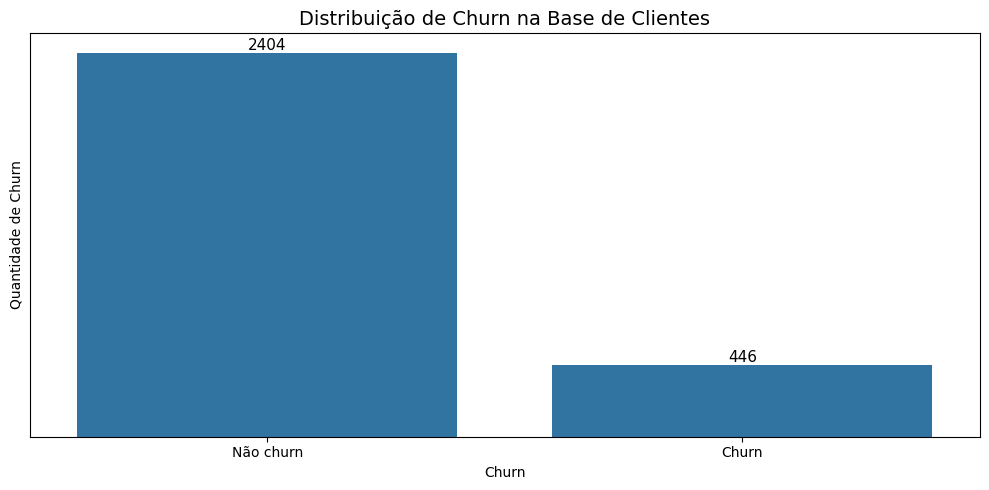

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="churn",
    order=[0, 1],
)

# adicionar rótulos de quantidade em cima das barras
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

# remover números do eixo Y
ax.set_yticks([])

# Mudando os valores no e yes por Não Churn e Churn 
plt.xticks(ticks=[0, 1],labels=['Não churn', 'Churn'], rotation=0)

plt.title("Distribuição de Churn na Base de Clientes", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Quantidade de Churn")

plt.tight_layout()
plt.show()

sns.despine(left=True)

In [23]:
def get_column_types(df):
    """
    Identifica colunas numéricas e categóricas em um DataFrame,
    compatível com pandas >= 2.x e futuras versões.
    """
    numeric_columns = df.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    
    categorical_columns = df.select_dtypes(
        include=["object", "string", "bool"]
    ).columns.tolist()

    return {
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns
    }


In [24]:
column_types = get_column_types(df)

print("Colunas Numéricas:")
for col in column_types["numeric_columns"]:
    print(f"- {col}")

print("\nColunas Categóricas:")
for col in column_types["categorical_columns"]:
    print(f"- {col}")

Colunas Numéricas:
- call_failure
- complains
- subscription_length
- charge_amount
- seconds_of_use
- frequency_of_use
- frequency_of_sms
- distinct_called_numbers
- age_group
- tariff_plan
- status
- age
- customer_value
- churn

Colunas Categóricas:


# Veriáveis Numéricas

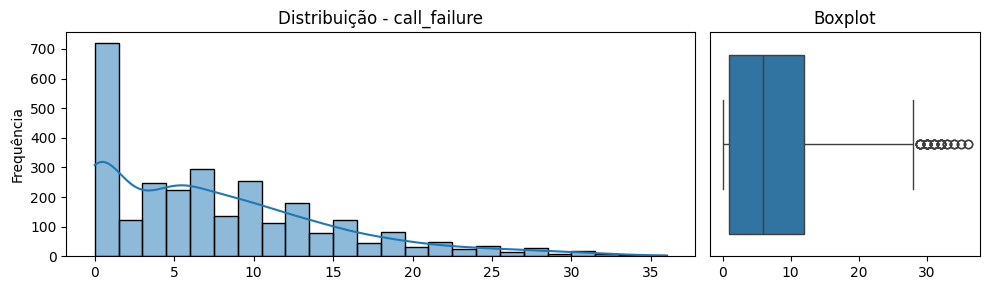

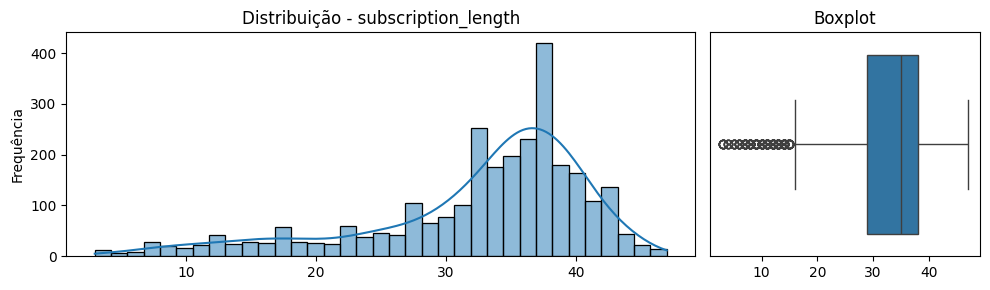

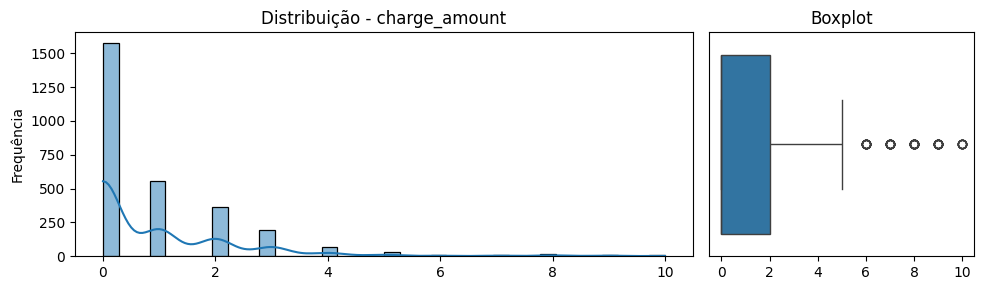

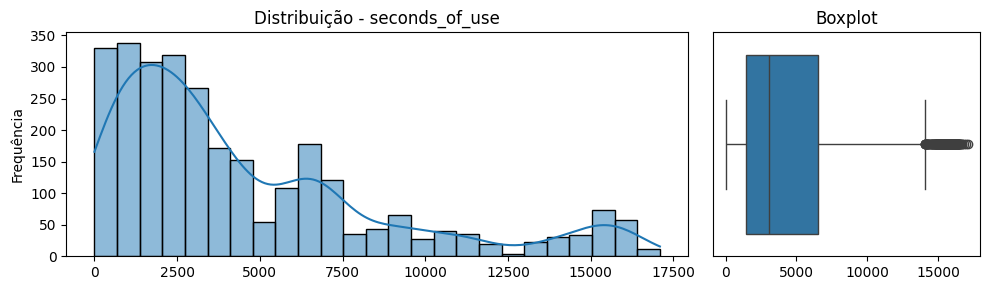

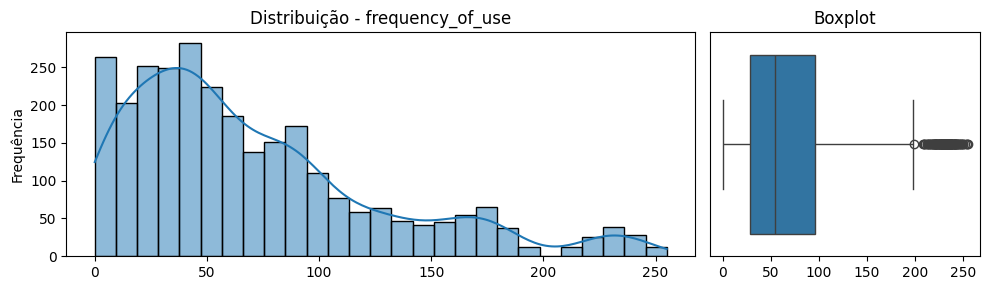

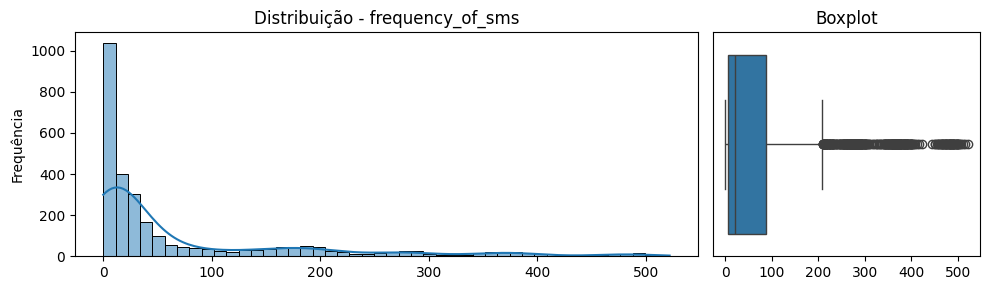

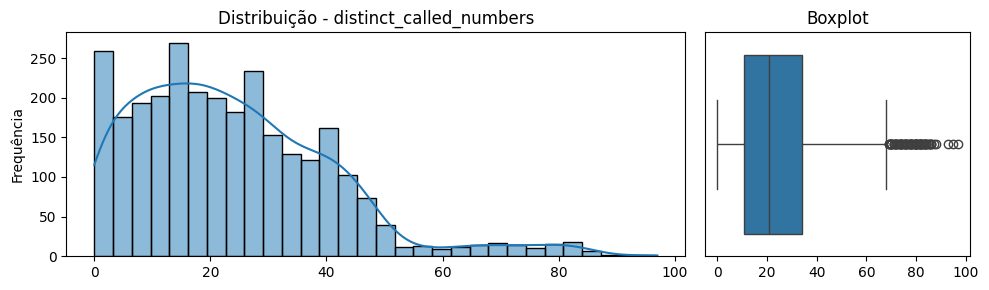

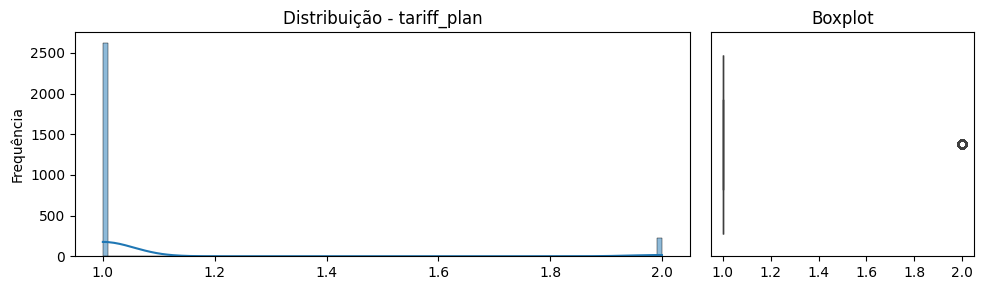

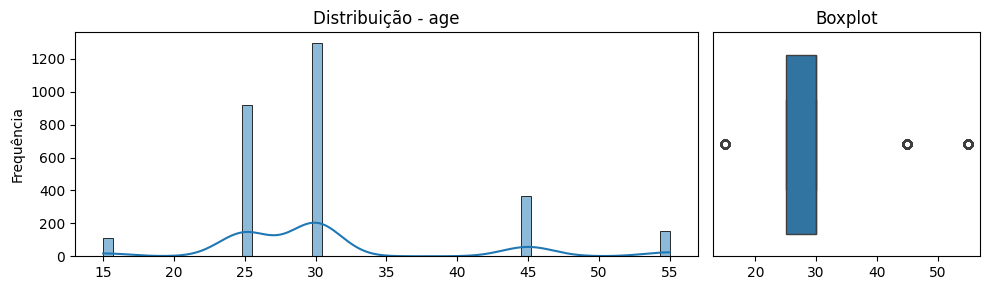

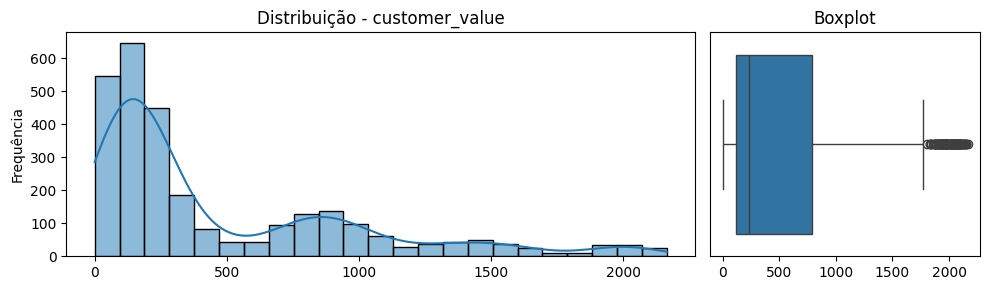

In [25]:
DROP_COLUMNS = ["churn", "complains", "status", "age_group", ]

for col in df.drop(DROP_COLUMNS, axis=1):
    fig, axes = plt.subplots(
        ncols=2,
        figsize=(10, 3),
        gridspec_kw={"width_ratios": [7, 3]}
    )
    
    # --- Distribuição (70%) ---
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribuição - {col}")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Frequência")
    
    # --- Boxplot (30%) ---
    sns.boxplot(
        x=df[col],
        ax=axes[1],
        orient="h"
    )
    axes[1].set_title("Boxplot")
    axes[1].set_xlabel("")
    axes[1].set_yticks([])
    
    plt.tight_layout()
    plt.show()

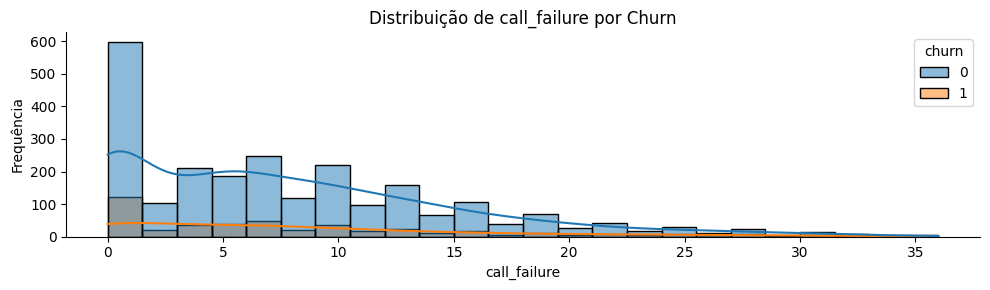

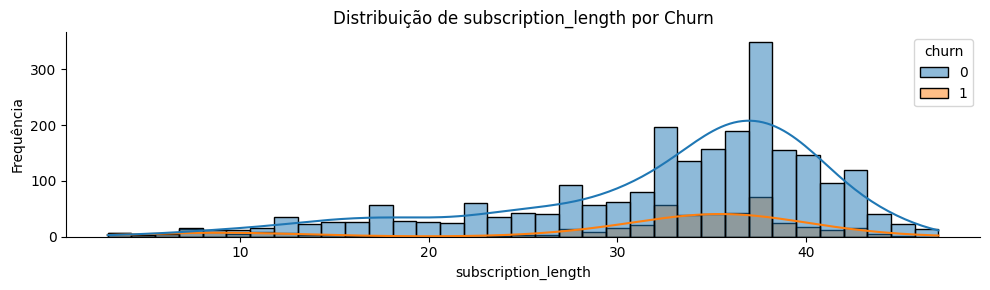

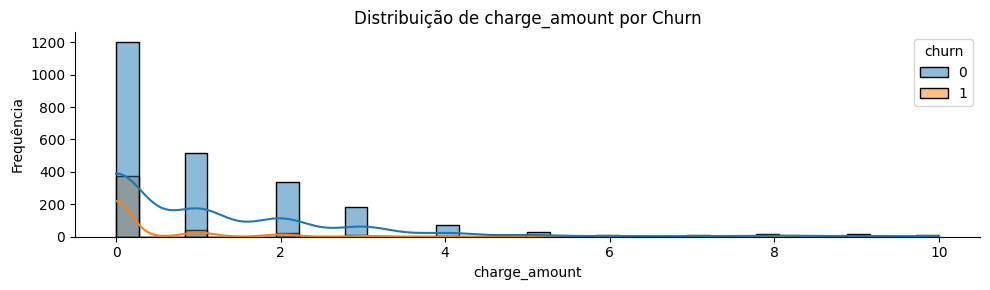

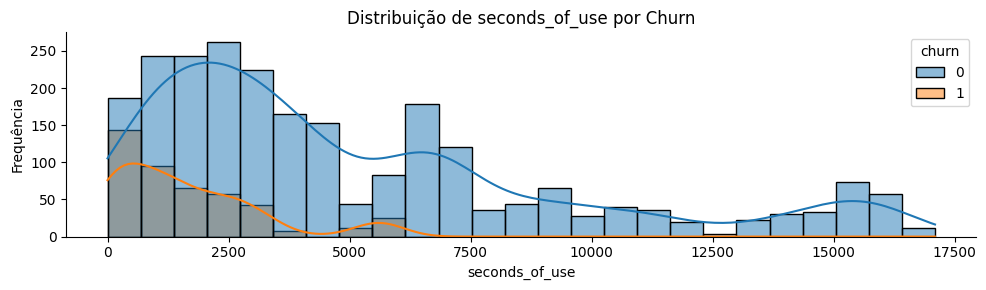

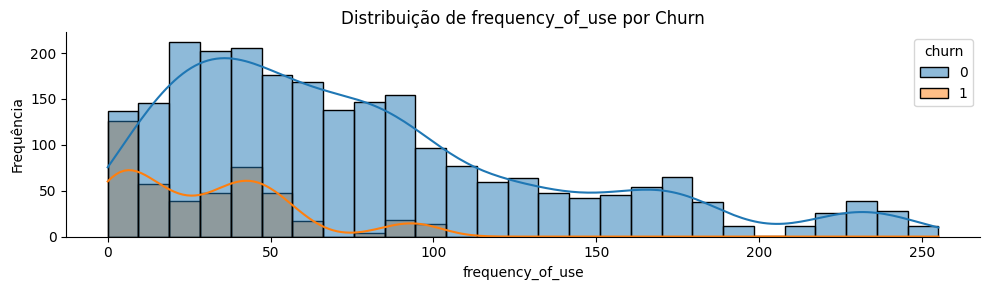

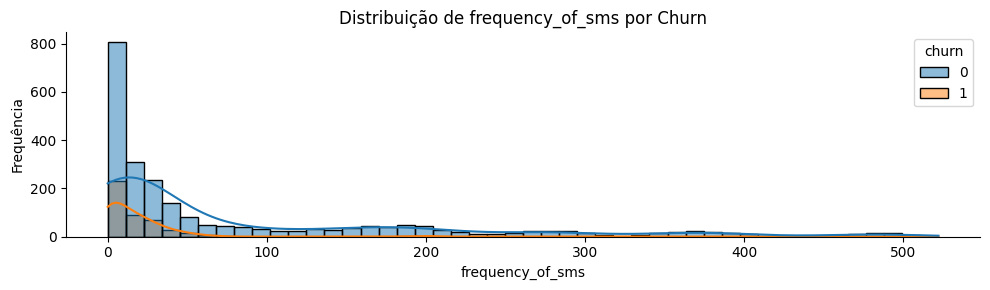

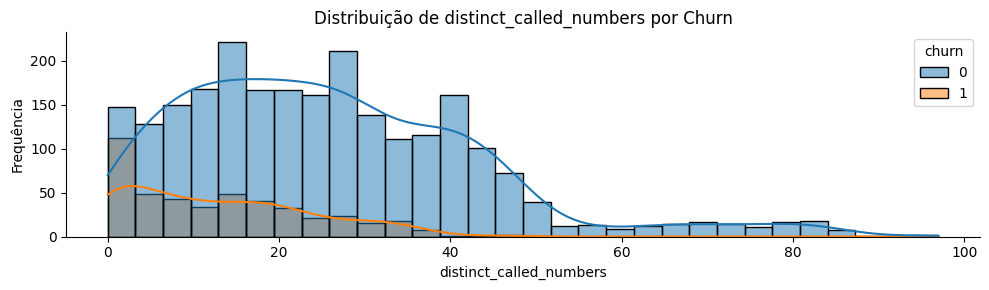

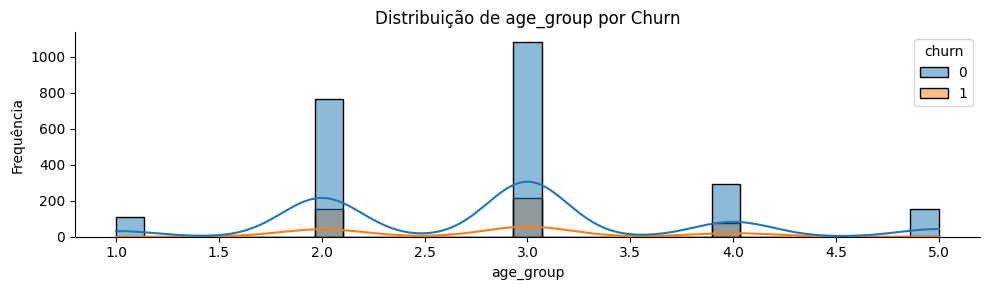

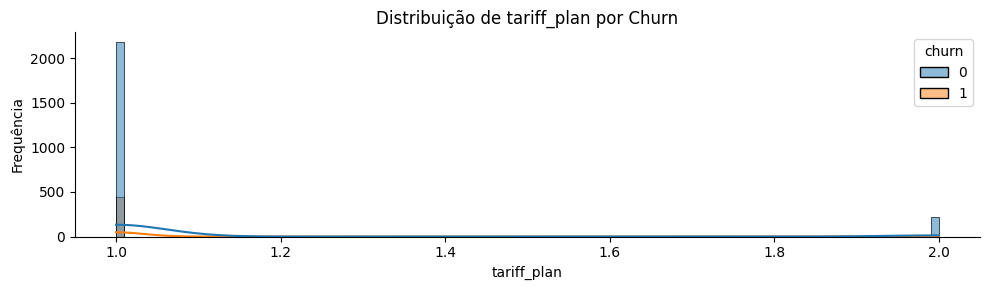

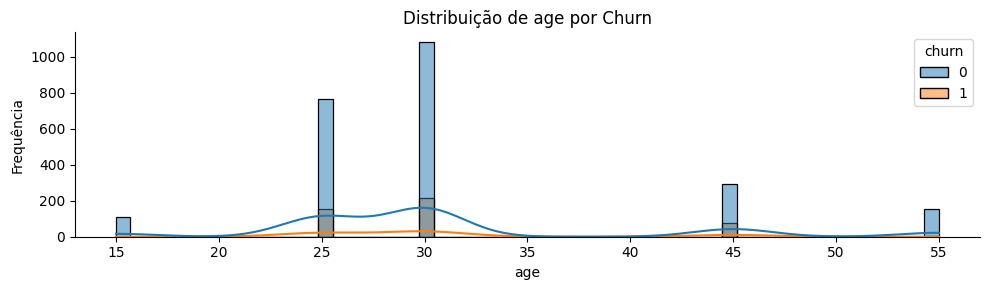

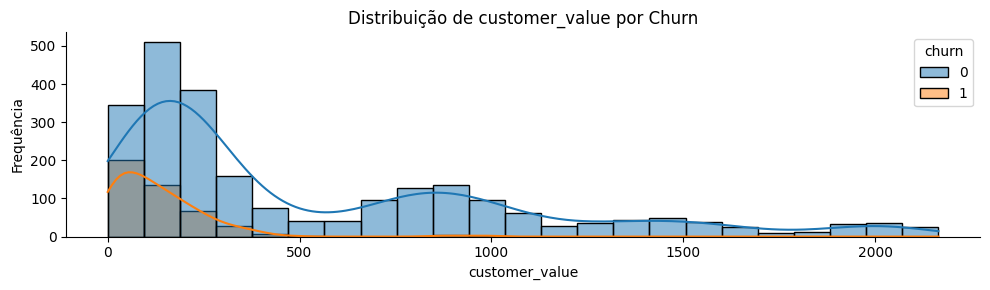

In [26]:
DROP_COLUMNS = ["churn", "complains", "status"]

for col in df.drop(DROP_COLUMNS, axis=1):
    plt.figure(figsize=(10, 3))
    
    sns.histplot(
        data=df,
        x=col,
        hue="churn",
        kde=True,
        common_norm=False,
        alpha=0.5
    )
    
    plt.title(f"Distribuição de {col} por Churn")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    
    sns.despine()
    plt.tight_layout()
    plt.show()


**Observação 1 – Variáveis de Uso (seconds_of_use, frequency_of_use e distinct_called_numbers)** Observa-se uma tendência consistente de menor churn entre clientes com maior nível de uso. Clientes menos ativos apresentam maior concentração de cancelamentos, sugerindo que o nível de engajamento é um fator importante para retenção.

**Observação 2 – Customer Behavior relacionado a valor e uso** Variáveis relacionadas ao comportamento de consumo apresentam padrões semelhantes, reforçando que clientes com menor utilização e menor engajamento tendem a apresentar maior risco de churn.

**Observação 3 – Subscription Length e Age** As variáveis `subscription_length` e `age` não apresentam separação clara entre as classes, sugerindo baixo poder discriminativo quando analisadas isoladamente. Avaliaremos no detalhe posteriormente na análise de correlação

**Observação 4 – Tariff Plan e Age Group** Essas variáveis apresentam distribuições semelhantes entre churn e não churn, indicando que, isoladamente, possuem menor impacto direto no cancelamento, podendo ainda contribuir em interações com outras variáveis. Avaliaremos no detalhe posteriormente na análise de correlação


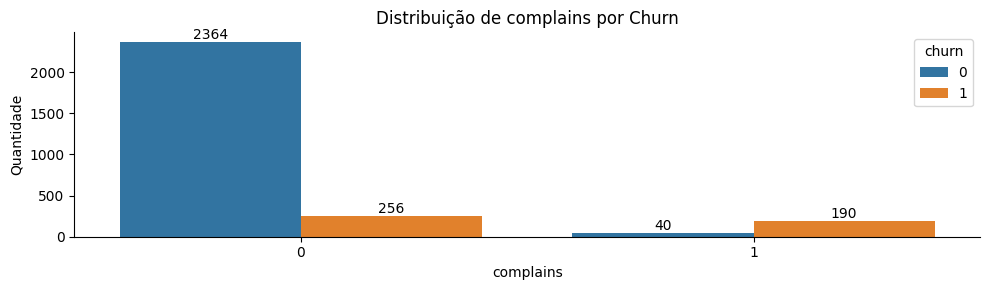

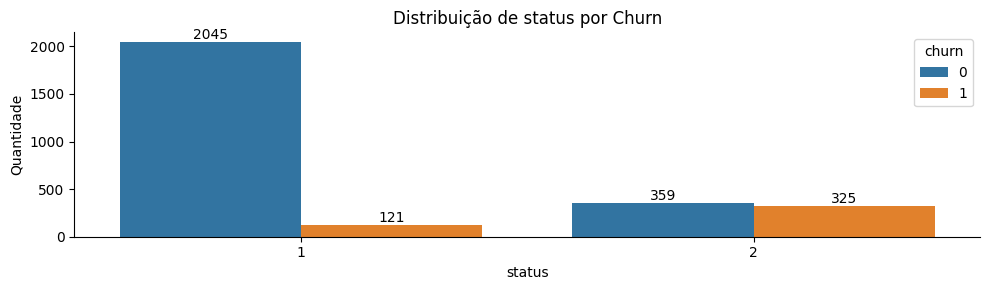

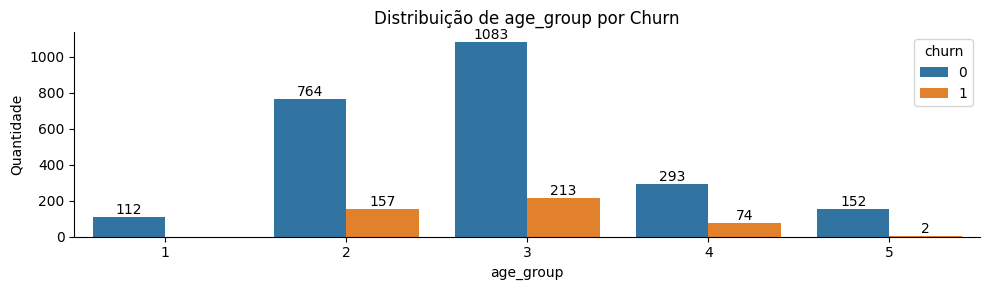

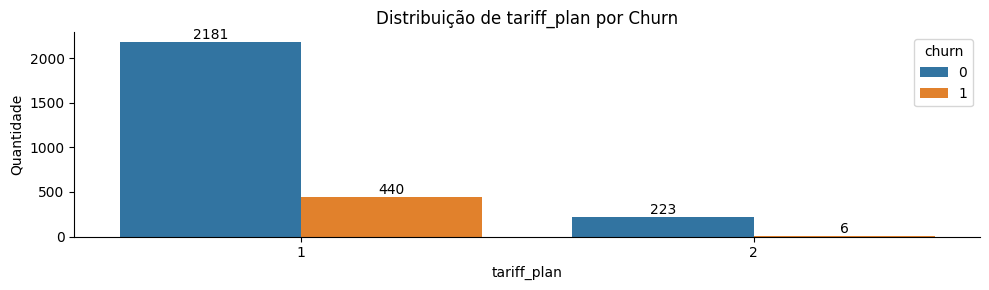

In [27]:
cols_to_plot = ["complains", "status", "age_group", "tariff_plan"]

for col in cols_to_plot:
    plt.figure(figsize=(10, 3))

    ax = sns.countplot(
        data=df,
        x=col,
        hue="churn"
    )

    # adicionar quantidade em cima das barras
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.title(f"Distribuição de {col} por Churn")
    plt.xlabel(col)
    plt.ylabel("Quantidade")

    sns.despine()
    plt.tight_layout()
    plt.show()

A análise das variáveis categóricas revelou padrões claros associados ao cancelamento de clientes, indicando fatores comportamentais e operacionais que podem influenciar diretamente a retenção.

**Observação 1 – Reclamações (Complains)** Clientes que registraram reclamações apresentam uma taxa de churn significativamente maior em comparação aos demais. Esse comportamento sugere que a insatisfação com o serviço é um dos principais preditores de cancelamento.

**Observação 2 – Status do Cliente**  
A variável `status` apresenta diferenças relevantes na proporção de churn entre suas categorias, indicando que o estado operacional ou contratual do cliente está associado ao risco de cancelamento.

**Observação 3 – Plano Tarifário (Tariff Plan)**  
A maior concentração de churn está associada ao plano tarifário predominante, enquanto outros planos apresentam menor incidência de cancelamento.

In [28]:
df.groupby("age_group")["age"].agg(["min", "max", "count"]).reset_index()

,age_group,min,max,count
0,1,15,15,112
1,2,25,25,921
2,3,30,30,1296
3,4,45,45,367
4,5,55,55,154


Foi analisada a correspondência entre a idade real e os grupos de idade, verificando os intervalos mínimo e máximo de cada grupo

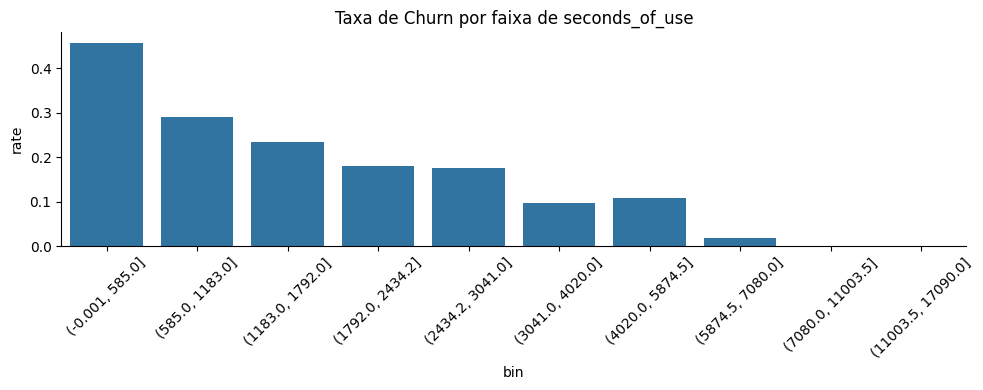

In [29]:
col = "seconds_of_use"

df["bin"] = pd.qcut(df[col], q=10, duplicates="drop")

churn_rate = (
    df.groupby("bin")["churn"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

churn_rate = churn_rate[churn_rate["churn"] == 1]

plt.figure(figsize=(10,4))

sns.barplot(
    data=churn_rate,
    x="bin",
    y="rate"
)

plt.title(f"Taxa de Churn por faixa de {col}")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

# Drop the bin column
df = df.drop(columns=['bin'])

Observa-se uma relação inversa clara entre o tempo de uso e a taxa de churn. Clientes com menor volume de uso apresentam probabilidade significativamente maior de cancelamento, enquanto clientes mais ativos tendem a permanecer.

Esse comportamento sugere que o nível de engajamento é um fator relevante para a permanência do cliente, indicando que variáveis relacionadas ao uso possuem potencial poder preditivo para modelos de churn.

In [30]:
# plt.figure(figsize=(14, 6))

# sns.boxplot(
#     data=df.drop("churn", axis=1),
#     orient="v"
# )

# plt.title("Boxplot das Variáveis Numéricas", fontsize=14)
# plt.xlabel("Variáveis")
# plt.ylabel("Valores")
# plt.xticks(rotation=45, ha="right")

# plt.tight_layout()
# plt.show()

In [31]:
df.describe().round(2)

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value,churn
count,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00,2850.00
mean,7.80,0.08,32.45,0.97,4534.24,70.48,73.79,23.87,2.84,1.08,1.24,31.08,474.99,0.16
std,7.33,0.27,8.72,1.55,4199.71,57.40,112.06,17.19,0.89,0.27,0.43,8.86,514.44,0.36
min,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,15.00,0.00,0.00
25%,1.00,0.00,29.00,0.00,1458.75,28.00,7.00,11.00,2.00,1.00,1.00,25.00,117.53,0.00
50%,6.00,0.00,35.00,0.00,3041.00,54.50,22.00,21.00,3.00,1.00,1.00,30.00,232.52,0.00
75%,12.00,0.00,38.00,2.00,6500.00,96.00,88.00,34.00,3.00,1.00,1.00,30.00,790.08,0.00
max,36.00,1.00,47.00,10.00,17090.00,255.00,522.00,97.00,5.00,2.00,2.00,55.00,2165.28,1.00


# Tratamento de outliers



Note que nem todo outlier deve ser removido. Em muitos problemas de negócio, especialmente churn, outliers podem ser exatamente os casos mais informativos.

Remover outliers sem entender o negócio é pior do que não tratar outliers.

O boxplot, por exemplo, marca como outlier qualquer ponto fora de Q1 − 1.5×IQR e Q3 + 1.5×IQR.
Isso não significa erro, significa apenas valor "raro", estatisticamente falando.

Não identificamos anomalias nos dados que justificassem a remoção de linhas. Caso, pelo entendimento de negócio, entendermos que existe valores inválidos, podemos aplicar técnicas para remover estes valores. 

# Análise de Correlação

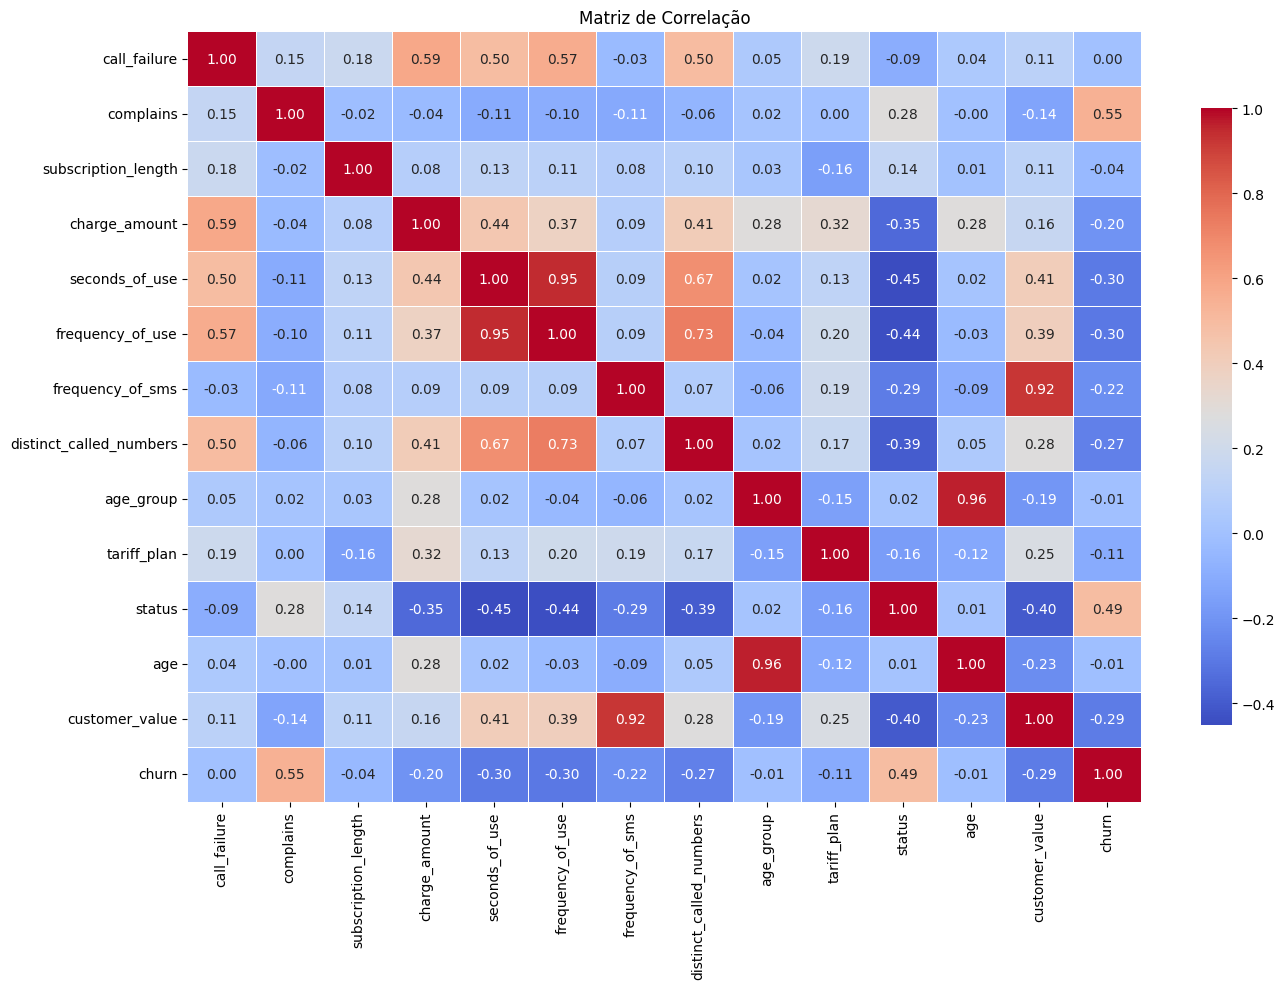

In [32]:
corr_matrix = df.corr()
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    # mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()


**Observação 1:** As variáveis relacionadas ao uso do serviço apresentam forte correlação entre si, destacando-se `seconds_of_use` e `frequency_of_use`, indicando possível redundância de informação.

**Observação 2:** A variável `age_group` apresenta alta correlação com `age`, o que é esperado, já que representa uma discretização direta dessa variável.

**Observação 3:** A variável `customer_value` apresenta correlação elevada com `frequency_of_sms`, sugerindo que o valor do cliente está fortemente associado ao volume de uso.

**Observação 4:** A variável alvo `churn` apresenta maior correlação positiva com `complains` e `status`, indicando que clientes com reclamações e determinados estados possuem maior probabilidade de cancelamento.

**Observação 5:** As variáveis relacionadas ao tempo e frequência de uso (`seconds_of_use`, `frequency_of_use`, `distinct_called_numbers`) apresentam correlação negativa moderada com `churn`, sugerindo que clientes mais ativos tendem a permanecer.

**Observação 6:** A maioria das demais variáveis apresenta correlação fraca com o target quando analisadas isoladamente, indicando que o problema pode depender de interações multivariadas para melhor poder preditivo.

# Feature Selection

In [33]:
df

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value,churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
2846,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
2847,8,1,11,2,1792,25,7,9,3,1,1,30,100.680,1
2848,26,0,38,9,10740,99,8,44,5,2,1,55,174.585,0


In [34]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif

X = df.drop(columns=["churn"]).copy()
y = df["churn"].astype(int)

selector = SelectKBest(score_func=mutual_info_classif, k=13)
selector.fit(X, y)

cols = selector.get_support(indices=True)
features_df_new = X.iloc[:, cols]

print("Features selecionadas:")
print(features_df_new.columns)

Features selecionadas:
Index(['call_failure', 'complains', 'subscription_length', 'charge_amount',
       'seconds_of_use', 'frequency_of_use', 'frequency_of_sms',
       'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'age',
       'customer_value'],
      dtype='str')


In [35]:
mask = selector.get_support()

cols_selecionadas = X.columns[mask]
cols_excluidas = X.columns[~mask]

print("Selecionadas:")
print(list(cols_selecionadas))

print("\nExcluídas:")
print(list(cols_excluidas))

Selecionadas:
['call_failure', 'complains', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'age', 'customer_value']

Excluídas:
[]


In [36]:
scores = pd.DataFrame({
    "feature": X.columns,
    "score": selector.scores_
}).sort_values("score", ascending=False)

scores

,feature,score
4,seconds_of_use,0.117386
1,complains,0.099865
10,status,0.098430
5,frequency_of_use,0.090988
12,customer_value,0.086422
7,distinct_called_numbers,0.054769
6,frequency_of_sms,0.046192
3,charge_amount,0.031420
8,age_group,0.030266
2,subscription_length,0.028406


Utilizei o SelectKBest como técnica inicial de feature selection por ser um método do tipo filter, que permite avaliar a relevância individual de cada variável em relação ao target de forma simples, rápida e estatisticamente fundamentada. Em um problema de churn, essa abordagem é especialmente útil para eliminar variáveis com baixo sinal logo nas etapas iniciais, reduzindo a dimensionalidade do problema, a complexidade do modelo e o risco de overfitting.

Para este projeto, optei por utilizar Mutual Information como score function, em vez de testes lineares como o f_classif, porque a mutual information é capaz de capturar relações não lineares entre as variáveis explicativas e o churn, além de não assumir normalidade ou linearidade dos dados, características raramente atendidas em bases de churn reais, que costumam apresentar distribuições assimétricas e comportamentos complexos.

Existem métodos mais sofisticados de feature selection, como abordagens Embedded (por exemplo, regularização L1 ou importâncias de modelos baseados em árvores) e Wrapper (como RFE), que são extremamente úteis e robustas. No entanto, optei por aplicá-las apenas após a construção de um baseline inicial. Essa estratégia evita custo computacional desnecessário com variáveis claramente irrelevantes e garante que métodos mais complexos sejam aplicados sobre um conjunto de features previamente filtrado.

Além disso, embora algumas variáveis apresentem alta correlação entre si (como *'seconds_of_use'* com *'frequency_of_use'* e *'age_group'* com *'age'*), a decisão de mantê-las no modelo depende do tipo de algoritmo utilizado. Em modelos lineares, como Regressão Logística, variáveis altamente correlacionadas tendem a introduzir multicolinearidade, tornando os coeficientes instáveis e dificultando a interpretação; nesses casos, opto por remover variáveis redundantes. Já em modelos baseados em árvores, como Random Forest ou Gradient Boosting, a colinearidade não representa um problema estrutural, pois o próprio modelo seleciona as variáveis mais informativas durante os splits. Nesses cenários, permito que variáveis correlacionadas entrem no modelo e utilizo métricas como ganho de split ou técnicas de interpretabilidade, como SHAP, para validar qual delas efetivamente contribui para a predição.

Encaro feature selection como um processo iterativo, e não como uma decisão pontual. O SelectKBest foi utilizado como um filtro inicial para redução de dimensionalidade, mas a definição final das variáveis sempre considera o conhecimento de negócio, análises de correlação, interpretabilidade do modelo e os resultados empíricos dos experimentos.

# Output Model

In [37]:
df.to_parquet("../data/trusted/train.parquet", index=False)

## Conclusão Geral da Análise Exploratória (EDA)

A análise exploratória permitiu compreender a estrutura, qualidade e principais padrões do dataset, confirmando que os dados se encontram consistentes, sem necessidade de etapas significativas de limpeza ou tratamento estrutural antes da modelagem.

As análises univariadas e bivariadas evidenciaram que o churn está fortemente associado a fatores comportamentais e operacionais, especialmente variáveis relacionadas a nível de uso do serviço, registro de reclamações, status do cliente e características do plano contratado. Em contrapartida, variáveis demográficas e algumas métricas isoladas apresentaram menor poder discriminativo quando analisadas individualmente.

Os resultados indicam que o cancelamento está mais relacionado ao engajamento e à experiência do cliente do que a características estáticas, reforçando hipóteses já observadas em problemas reais de retenção em telecomunicações e serviços recorrentes.

Com base nesses achados, o dataset encontra-se apto para as próximas etapas do projeto, que incluem preparação de dados, engenharia de atributos e construção dos primeiros modelos preditivos, priorizando variáveis com maior potencial explicativo e explorando interações entre comportamento, utilização e satisfação do cliente.
